In [3]:
import pandas as pd

# Загрузка CSV файла в DataFrame
df = pd.read_csv('transaction.csv')

# Преобразование колонки 'tr_date' в тип datetime
df['trDte'] = pd.to_datetime(df['trDte'], format='%d.%m.%Y')

Создай функцию aggregate_client_daily_items(df), которая:
1. Группирует транзакции по (client, tr_date, item, item_group)
2. Суммирует quantity и amount для каждой группы
3. Возвращает DataFrame с колонками: client, visit_date, item, item_group, quantity, amount
4. Отсортирован по client, visit_date, item
Комментарий: bcode (номер чека) игнорируем — нас интересует, что клиент купил в день, а не структура чеков.


In [4]:
def aggregate_client_daily_items(df):
    """
    Агрегирует транзакции по клиенту, дате, товару и группе товара.
    
    Группирует данные по (client, tr_date, item, item_group) и суммирует 
    количество (quantity) и сумму (amount). Используется для анализа 
    ежедневной покупательской активности без привязки к отдельным чекам.
    
    Параметры:
        df (pd.DataFrame): исходный DataFrame с колонками 
        ['client', 'tr_date', 'item', 'item_group', 'quantity', 'amount']
    
    Возвращает:
        pd.DataFrame: с колонками
            - client
            - visit_date (tr_date)
            - item
            - item_group
            - quantity (суммарное)
            - amount (суммарное)
        Отсортирован по client, visit_date, item.
    """
    # Проверка наличия необходимых колонок
    required_cols = {'client', 'tr_date', 'item', 'item_group', 'quantity', 'amount'}
    if not required_cols.issubset(df.columns):
        missing = required_cols - set(df.columns)
        raise KeyError(f"Отсутствуют колонки: {missing}")
    
    # Группировка и агрегация
    result = (df
              .groupby(['client', 'tr_date', 'item', 'item_group'], as_index=False)
              .agg({'quantity': 'sum', 'amount': 'sum'}))
    
    # Переименование tr_date в visit_date и сортировка
    result = (result
              .rename(columns={'tr_date': 'visit_date'})
              .sort_values(by=['client', 'visit_date', 'item'])
              .reset_index(drop=True))
    
    return result

Напиши функцию calculate_client_profile_at_date(visits_df,
observation_end_date).
Функция должна:
1. Фильтровать визиты СТРОГО ДО observation_end_date
(visit_date < observation_end_date)
Это важно для метода аналогий — нет утечки данных!
2. Для каждого клиента рассчитать RFM признаки:
 - Recency: количество дней между последним визитом и
observation_end_date
- Frequency: количество УНИКАЛЬНЫХ ДАТ визитов (не товаров!)
 - Monetary: общая сумма всех покупок
3. Дополнительные признаки:
 - last_visit_date: дата последнего визита
 - total_quantity: общее количество товаров
 - avg_check: средний чек (Monetary / Frequency)
- total_unique_items: количество уникальных товаров за
историю
 - avg_items_per_visit: среднее количество товаров на визит
 - weekend_visits: количество визитов в субботу и воскресенье
 - amount_last_visit: сумма последнего визита
 - avg_num_of_visits: средний интервал между визитами
4. Вернуть DataFrame с профилями, отсортированный по client.

In [5]:
import pandas as pd
import numpy as np

def calculate_client_profile_at_date(visits_df, observation_end_date):
    """
    Формирует профиль клиентов на указанную дату, используя только историю ДО этой даты.
    Предотвращает утечку данных — критично для прогнозных моделей.

    Параметры:
        visits_df (pd.DataFrame): с колонками 'client', 'visit_date', 'item', 'quantity', 'amount'
        observation_end_date (str или datetime): дата, на которую строится срез (например, '2019-10-01')

    Возвращает:
        pd.DataFrame: профиль клиентов с RFM и дополнительными признаками, отсортированный по 'client'
    """
    # Преобразуем даты
    observation_end_date = pd.to_datetime(observation_end_date)
    visits_df = visits_df.copy()
    visits_df['visit_date'] = pd.to_datetime(visits_df['visit_date'])

    # 1. Фильтрация: только визиты ДО observation_end_date
    historical_data = visits_df[visits_df['visit_date'] < observation_end_date]

    if historical_data.empty:
        raise ValueError("Нет данных о визитах до указанной даты.")

    # Группировка по клиенту
    grouped = historical_data.groupby('client')

    # 2. Основные RFM-признаки
    profile = grouped.agg(
        # Последняя дата визита
        last_visit_date=('visit_date', 'max'),
        # Frequency: количество уникальных дат визитов
        frequency=('visit_date', 'nunique'),
        # Monetary: сумма всех покупок
        monetary=('amount', 'sum'),
        # Общее количество купленных товаров
        total_quantity=('quantity', 'sum')
    ).reset_index()

    # Recency: количество дней от последнего визита до observation_end_date
    profile['last_visit_date'] = pd.to_datetime(profile['last_visit_date'])
    profile['recency'] = (observation_end_date - profile['last_visit_date']).dt.days

    # Средний чек
    profile['avg_check'] = profile['monetary'] / profile['frequency']

    # 3. Дополнительные признаки

    # Количество уникальных товаров
    unique_items = historical_data.groupby('client')['item'].nunique()
    profile = profile.merge(unique_items.rename('total_unique_items'), left_on='client', right_index=True, how='left')

    # Среднее количество товаров на визит
    items_per_visit = (historical_data.groupby('client')
                       .agg(total_items=('quantity', 'sum'), n_visits=('visit_date', 'nunique'))
                       .apply(lambda x: x['total_items'] / x['n_visits'], axis=1))
    profile = profile.merge(items_per_visit.rename('avg_items_per_visit'), left_on='client', right_index=True, how='left')

    # Визиты в выходные (суббота=5, воскресенье=6)
    historical_data['weekday'] = historical_data['visit_date'].dt.weekday
    weekend_visits = (historical_data[historical_data['weekday'].isin([5, 6])]
                      .groupby('client').size())
    profile = profile.merge(weekend_visits.rename('weekend_visits'), left_on='client', right_index=True, how='left')
    profile['weekend_visits'] = profile['weekend_visits'].fillna(0).astype(int)

    # Сумма последнего визита
    last_visit_amount = (historical_data.sort_values('visit_date')
                         .groupby('client')
                         .tail(1)[['client', 'amount']]
                         .set_index('client'))
    profile = profile.merge(last_visit_amount.rename({'amount': 'amount_last_visit'}, axis=1),
                            left_on='client', right_index=True, how='left')
    profile['amount_last_visit'] = profile['amount_last_visit'].fillna(0)

    # Средний интервал между визитами (в днях)
    def avg_visit_interval(dates):
        if len(dates) < 2:
            return 0  # не можем посчитать интервал
        sorted_dates = sorted(dates)
        intervals = [(d2 - d1).days for d1, d2 in zip(sorted_dates, sorted_dates[1:])]
        return np.mean(intervals)
    
    intervals = historical_data.groupby('client')['visit_date'].apply(avg_visit_interval)
    profile = profile.merge(intervals.rename('avg_num_of_visits'), left_on='client', right_index=True, how='left')
    profile['avg_num_of_visits'] = profile['avg_num_of_visits'].fillna(0)

    # 4. Финальная сортировка
    return profile.sort_values('client').reset_index(drop=True)

Напиши функцию mark_events(visits_df,
result_start_date, result_end_date).
Функция должна:
1. Получить уникальный список всех client из
visits_df
2. Фильтровать визиты в СТРОГОМ диапазоне:
 visit_date >= result_start_date И visit_date <
result_end_date
3. Определить, какие клиенты имели хотя бы один
визит в этот период
4. Вернуть DataFrame с двумя колонками:
 - client: все уникальные клиенты
 - event: True если клиент посетил магазин в
период, иначе False
Важно: это ТОЛЬКО разметка события, без признаков!


In [6]:
def mark_events(visits_df, result_start_date, result_end_date):
    """
    Размечает клиентов по факту посещения в заданном периоде.

    Параметры:
        visits_df (pd.DataFrame): с колонками 'client', 'visit_date'
        result_start_date (str или datetime): начало периода (включительно)
        result_end_date (str или datetime): конец периода (исключительно)

    Возвращает:
        pd.DataFrame: с колонками
            - client: все уникальные клиенты
            - event: True, если был визит в [start, end), иначе False
    """
    # Преобразуем даты в datetime при необходимости
    result_start_date = pd.to_datetime(result_start_date)
    result_end_date = pd.to_datetime(result_end_date)

    # 1. Получаем всех уникальных клиентов
    all_clients = visits_df['client'].unique()
    clients_df = pd.DataFrame({'client': all_clients})

    # 2. Фильтрация визитов в строгом диапазоне: [start, end)
    mask = (visits_df['visit_date'] >= result_start_date) & \
           (visits_df['visit_date'] < result_end_date)
    
    target_visits = visits_df[mask]

    # 3. Определяем клиентов, которые были в этот период
    clients_in_period = target_visits['client'].unique()
    
    # 4. Добавляем признак события
    clients_df['event'] = clients_df['client'].isin(clients_in_period)

    return clients_df

Напиши функцию create_training_sample(profile_df,
events_df).
Функция должна:
1. Выполнить inner join профиля и событий по
'client’ (оставляем только клиентов, которые
есть в обоих датафреймах)
2. Проверить, что целевая переменная 'event' не
содержит пропусков
3. Удалить служебные колонки с датами (они не
нужны для моделирования)
4. Убедиться что в выборке есть оба класса для
события (True и False)
5. Вернуть готовую выборку
На выходе: DataFrame где каждая строка = (профиль
клиента + событие).


In [7]:
def create_training_sample(profile_df, events_df):
    """
    Создаёт обучающую выборку, объединяя профиль клиента и целевую переменную 'event'.
    
    Параметры:
        profile_df (pd.DataFrame): профиль клиентов с колонкой 'client' и признаками
        events_df (pd.DataFrame): метки событий с колонками 'client', 'event'
    
    Возвращает:
        pd.DataFrame: готовая выборка train_data с требуемыми колонками
    """
    # 1. Inner join по 'client'
    merged = profile_df.merge(events_df, on='client', how='inner')
    
    if merged.empty:
        raise ValueError("Нет общих клиентов в profile_df и events_df. Объединение вернуло пустой DataFrame.")
    
    # 2. Проверка пропусков в 'event'
    if merged['event'].isnull().any():
        raise ValueError("Целевая переменная 'event' содержит пропущенные значения.")
    
    # 3. Удаление колонок с датами (например, 'last_visit_date' и др.)
    date_cols = [col for col in merged.columns if 'date' in col.lower()]
    cols_to_drop = [col for col in date_cols if col in merged.columns]
    if cols_to_drop:
        merged = merged.drop(columns=cols_to_drop)
    
    # 4. Проверка наличия обоих классов
    if not (merged['event'].nunique() == 2 and merged['event'].isin([True, False]).all()):
        unique_classes = sorted(merged['event'].unique())
        raise ValueError(f"Ожидаются оба класса (True и False) в 'event'. Найдены: {unique_classes}")
    
    # 5. Выбор только требуемых колонок
    required_columns = [
        'client',
        'frequency',
        'monetary',
        'total_quantity',
        'total_unique_items',
        'recency',
        'avg_check',
        'avg_items_per_visit',
        'weekend_visits',
        'amount_last_visit',
        'event',
        'avg_num_of_visits'
    ]
    
    missing_in_result = [col for col in required_columns if col not in merged.columns]
    if missing_in_result:
        raise KeyError(f"Не хватает колонок для train_data: {missing_in_result}")
    
    train_data = merged[required_columns].reset_index(drop=True)
    
    return train_data

# Пример использования:
# train_data = create_training_sample(profile_df=profile1, events_df=events1)

Создай профиль клиентов на дату: "2019-09-01", События в периоде: ['2019-09-01', '2019- 10-01'), все задай в переменную 'train_data'

In [8]:
# 1. Создание профиля клиентов на дату 2019-09-01
profile1 = calculate_client_profile_at_date(
    visits_df=daily_items,
    observation_end_date='2019-09-01'
)

print(f"✅ profile1 создан — профиль на 2019-09-01: {len(profile1)} клиентов")

# 2. Разметка событий: посещения в период [2019-09-01, 2019-10-01)
events1 = mark_events(
    visits_df=daily_items,
    result_start_date='2019-09-01',
    result_end_date='2019-10-01'
)

print(f"✅ events1 создан — события за сентябрь 2019: {len(events1)} клиентов")
print(f"   Доля посетивших (event=True): {events1['event'].mean():.2%}")

# 3. Создание обучающей выборки
train_data = create_training_sample(profile_df=profile1, events_df=events1)

print(f"✅ train_data успешно создан")
print(f"   Итоговый размер: {train_data.shape[0]} строк, {train_data.shape[1]} столбцов")
print(f"   Распределение целевой переменной:\n{train_data['event'].value_counts()}")

NameError: name 'daily_items' is not defined

Используя те же функции, создай вторую
выборку:
- Профиль на дату: '2019-10-01'
- События в периоде: ['2019-10-01', '2019-
11-01')
Сохрани результаты в датафреймы profile2,
events2, test_data.


+ проверка на наличие всех столбцов

In [ ]:
# 1. Убедитесь, что df загружен
df = pd.read_csv('transaction.csv')

# 2. Переименуйте колонки, если они отличаются
df = df.rename(columns={
    'trDte': 'tr_date',        # или 'Date', 'date' → в 'tr_date'
    'clientID': 'client',          # или 'CustomerID', 'cust' → в 'client'
    'item': 'item',
    'itemGroup': 'item_group',  # или 'category', 'Category' → в 'item_group'
    'quantity': 'quantity',
    'amount': 'amount',
    'bcode': 'bcode'
})

# Если имена другие — подставьте актуальные!
# Пример: если у вас 'Date' и 'CustomerID':
# df = df.rename(columns={'Date': 'tr_date', 'CustomerID': 'client', 'Category': 'item_group'})

# 3. Преобразуйте tr_date в datetime
df['tr_date'] = pd.to_datetime(df['tr_date'], format= "%d.%m.%Y")

# 4. Проверьте, что все нужные колонки теперь есть
required = ['client', 'tr_date', 'item', 'item_group', 'quantity', 'amount']
assert all(col in df.columns for col in required), f"Не хватает колонок: {[col for col in required if col not in df.columns]}"

print("✅ Все колонки на месте.")

# 5. Запустите агрегацию (теперь функция должна работать)
daily_items = aggregate_client_daily_items(df)

print(f"✅ daily_items создан: {len(daily_items)} строк")
print(daily_items.head())

✅ Все колонки на месте.
✅ daily_items создан: 1003083 строк
     client visit_date      item     item_group  quantity  amount
0   client1 2018-01-22  sku10765  Лаки и краски         1      29
1   client1 2018-01-22  sku13695  Стойматериалы         5    1535
2   client1 2018-01-22  sku29083  Лаки и краски         2     310
3   client1 2018-01-22   sku2954  Лаки и краски         1     399
4  client10 2019-08-05   sku1893    Инструменты         1      79


In [ ]:
# 1. Создание профиля клиента на дату 2019-10-01
profile2 = calculate_client_profile_at_date(
    visits_df=daily_items,
    observation_end_date='2019-10-01'
)

print("✅ Профиль на 2019-10-01 создан.")
print(f"   Количество клиентов: {len(profile2)}")

# 2. Разметка событий: посещения в период [2019-10-01, 2019-11-01)
events2 = mark_events(
    visits_df=daily_items,
    result_start_date='2019-10-01',
    result_end_date='2019-11-01'
)

print("✅ События для периода 2019-10-01 – 2019-11-01 размечены.")
print(f"   Количество клиентов: {len(events2)}")
print(f"   Количество событий (event=True): {events2['event'].sum()}")

# 3. Формирование тестовой выборки
test_data = create_training_sample(
    profile_df=profile2,
    events_df=events2
)

print("✅ Тестовая выборка создана.")
print(f"   Итоговый размер: {test_data.shape[0]} строк, {test_data.shape[1]} признаков")
print(f"   Доля событий (event=True): {test_data['event'].mean():.2%}")


C:\Users\Alex\AppData\Local\Temp\ipykernel_11876\2113869498.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  historical_data['weekday'] = historical_data['visit_date'].dt.weekday


✅ Профиль на 2019-10-01 создан.
   Количество клиентов: 41196
✅ События для периода 2019-10-01 – 2019-11-01 размечены.
   Количество клиентов: 42746
   Количество событий (event=True): 9324
✅ Тестовая выборка создана.
   Итоговый размер: 41196 строк, 12 признаков
   Доля событий (event=True): 18.87%


Сохрани обучающую и тестовую выборки в csvфайлы


In [ ]:
# Сохранение обучающей и тестовой выборок в CSV-файлы

# Убедимся, что папка для сохранения существует
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

# Сохранение обучающей выборки (предполагается, что она называется train_data)
if 'train_data' in locals() or 'train_data' in globals():
    train_file = os.path.join(output_dir, 'train_data.csv')
    train_data.to_csv(train_file, index=False)
    print(f"✅ Обучающая выборка сохранена: {train_file}")
else:
    print("⚠️ Переменная 'train_data' не найдена. Убедитесь, что обучающая выборка создана.")

# Сохранение тестовой выборки (test_data)
test_file = os.path.join(output_dir, 'test_data.csv')
test_data.to_csv(test_file, index=False)
print(f"✅ Тестовая выборка сохранена: {test_file}")

# Проверка: выведем первые строки test_data
print("\n📂 Пример данных из test_data:")
print(test_data.head())

✅ Обучающая выборка сохранена: data\train_data.csv
✅ Тестовая выборка сохранена: data\test_data.csv

📂 Пример данных из test_data:
        client  frequency  monetary  total_quantity  total_unique_items  \
0      client1          1      2273               9                   4   
1     client10          1      4757               3                   3   
2    client100          1      7299               1                   1   
3   client1000         13     36495             166                  31   
4  client10000          1      8495               5                   5   

   recency    avg_check  avg_items_per_visit  weekend_visits  \
0      617  2273.000000             9.000000               0   
1       57  4757.000000             3.000000               0   
2      146  7299.000000             1.000000               0   
3       17  2807.307692            12.769231              16   
4      426  8495.000000             5.000000               0   

   amount_last_visit  event  avg_

1. Загрузи данные из train_data.csv, test_data.csv
2. Создай BinningProcess, обучи на X_train, y_train
3. Получи IV summary (отсортировано)
4. Выведи таблицы WoE для топ-5 признаков
5. Нарисуй 5 диаграмм WoE
6. Трансформируй X_train и X_test в WoE
7. Сохрани train_woe.csv и test_woe.csv

In [ ]:
import pandas as pd
from optbinning import BinningProcess
import numpy as np

# 1. Загружаем данные
train_data = pd.read_csv('data/train_data.csv')
test_data = pd.read_csv('data/test_data.csv')

# 2. Выбираем ОДИНАКОВЫЕ признаки для train и test
# Сначала определим какие признаки использовать
common_cols = list(set(train_data.columns) & set(test_data.columns))
print(f"Общие колонки: {len(common_cols)}")

# Исключаем целевую переменную
features = [col for col in common_cols if col != 'event']
print(f"Признаки: {features}")

# 3. Подготавливаем данные
X_train = train_data[features].copy()
X_test = test_data[features].copy()
y_train = train_data['event'].copy()
y_test = test_data['event'].copy()

# 4. Конвертируем ВСЕ в числовой формат
for col in features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# 5. Заполняем пропуски
X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)

# 6. СОБИРАЕМ ВСЕ КОЛОНКИ В ОДИН СПИСОК В ТОЧНОМ ПОРЯДКЕ
feature_list = list(X_train.columns)
print(f"Используем {len(feature_list)} признаков")
print(f"Признаки: {feature_list}")

# 7. Создаем BinningProcess с ЭТИМ списком
binning_process = BinningProcess(variable_names=feature_list)

# 8. Обучение
binning_process.fit(X_train, y_train)

# 9. Трансформация - используем ТОТ ЖЕ список признаков
X_train_woe = binning_process.transform(X_train[feature_list], metric="woe")
X_test_woe = binning_process.transform(X_test[feature_list], metric="woe")

# 10. Сохраняем
train_woe = pd.DataFrame(X_train_woe, columns=feature_list)
train_woe['event'] = y_train.values

test_woe = pd.DataFrame(X_test_woe, columns=feature_list)
test_woe['event'] = y_test.values

train_woe.to_csv('data/train_woe_fixed.csv', index=False)
test_woe.to_csv('data/test_woe_fixed.csv', index=False)

print("✅ Готово!")

Общие колонки: 12
Признаки: ['client', 'recency', 'avg_items_per_visit', 'frequency', 'total_quantity', 'monetary', 'total_unique_items', 'avg_num_of_visits', 'amount_last_visit', 'weekend_visits', 'avg_check']
Используем 11 признаков
Признаки: ['client', 'recency', 'avg_items_per_visit', 'frequency', 'total_quantity', 'monetary', 'total_unique_items', 'avg_num_of_visits', 'amount_last_visit', 'weekend_visits', 'avg_check']
✅ Готово!


In [ ]:
import pandas as pd
from optbinning import BinningProcess

# 1. Загрузка данных — критически важно присвоить результат
try:
    train_data = pd.read_csv('data/train_data.csv')
    test_data = pd.read_csv('data/test_data.csv')
except FileNotFoundError as e:
    raise FileNotFoundError(f"Файл не найден: {e}")

if train_data is None or test_data is None:
    raise ValueError("pd.read_csv вернул None — это невозможно. Проверьте, не перезаписали ли вы функцию.")

print(f"✅ Загружено: train_data {train_data.shape}, test_data {test_data.shape}")

# 2. Явно определяем нужные признаки
required_features = [
    'recency',
    'frequency',
    'monetary',
    'total_quantity',
    'total_unique_items',
    'avg_check',
    'avg_items_per_visit',
    'weekend_visits',
    'amount_last_visit'
]

# 3. Проверка наличия колонок
missing_train = [col for col in required_features if col not in train_data.columns]
missing_test = [col for col in required_features if col not in test_data.columns]

if missing_train:
    raise KeyError(f"В train_data нет колонок: {missing_train}")
if missing_test:
    raise KeyError(f"В test_data нет колонок: {missing_test}")

# 4. Отбор признаков
X_train = train_data[required_features].copy()  # .copy() — чтобы избежать SettingWithCopyWarning
X_test = test_data[required_features].copy()
y_train = train_data['event'].copy()
y_test = test_data['event'].copy()

# 5. Приведение к числовому типу
for col in required_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# 6. Заполнение NaN (если есть)
if X_train.isnull().any().any():
    print("⚠️ NaN в X_train — заполняем средним по признакам")
    X_train.fillna(X_train.mean(numeric_only=True), inplace=True)

if X_test.isnull().any().any():
    print("⚠️ NaN в X_test — заполняем средним из X_train")
    train_means = X_train.mean(numeric_only=True)
    X_test.fillna(train_means, inplace=True)

# 7. Создание и обучение BinningProcess
binning_process = BinningProcess(variable_names=required_features)

print("Обучение BinningProcess...")
binning_process.fit(X_train, y_train)
print("✅ Обучение завершено")

# 8. Трансформация в WoE
print("Трансформация train/test в WoE...")
X_train_woe = binning_process.transform(X_train, metric="woe")
X_test_woe = binning_process.transform(X_test, metric="woe")
print("✅ Трансформация завершена")

# 9. Создание итоговых DataFrame с правильными колонками
train_woe = pd.DataFrame(X_train_woe, columns=required_features)
train_woe['event'] = y_train.values

test_woe = pd.DataFrame(X_test_woe, columns=required_features)
test_woe['event'] = y_test.values

# 10. Сохранение
train_woe.to_csv('data/train_woe.csv', index=False)
test_woe.to_csv('data/test_woe.csv', index=False)

print("✅ WoE-данные успешно сохранены:")
print("  - data/train_woe.csv")
print("  - data/test_woe.csv")
# ... предыдущий код: загрузка, подготовка, binning_process.fit()

# 7. Создание и обучение BinningProcess
binning_process = BinningProcess(variable_names=required_features)

print("Обучение BinningProcess...")
binning_process.fit(X_train, y_train)
print("✅ Обучение завершено")

# 🔽 СЮДА ВСТАВЬТЕ СОХРАНЕНИЕ binning_process
import pickle

with open("binning_process.pkl", "wb") as f:
    pickle.dump(binning_process, f)

print("✅ binning_process сохранён в 'binning_process.pkl'")
# 🔼

# Продолжение: трансформация и сохранение WoE
print("Трансформация train/test в WoE...")
X_train_woe = binning_process.transform(X_train, metric="woe")
# ...
with open("binning_process.pkl", "rb") as f:
    binning_process_loaded = pickle.load(f)

# Теперь можем использовать загруженную модель
X_new_woe = binning_process_loaded.transform(X_new, metric="woe")


✅ Загружено: train_data (39906, 12), test_data (41196, 12)
Обучение BinningProcess...
✅ Обучение завершено
Трансформация train/test в WoE...
✅ Трансформация завершена
✅ WoE-данные успешно сохранены:
  - data/train_woe.csv
  - data/test_woe.csv
Обучение BinningProcess...
✅ Обучение завершено
✅ binning_process сохранён в 'binning_process.pkl'
Трансформация train/test в WoE...


In [ ]:
import pandas as pd
import pickle

# 1. Загрузка тестовых или новых данных
# Если вы хотите использовать test_data.csv — раскомментируйте:
X_new = pd.read_csv("data/test_data.csv")

# Если вы хотите использовать отдельный файл new_data.csv — раскомментируйте:
# X_new = pd.read_csv("data/new_data.csv")

# 2. Убедимся, что загрузили данные
if 'X_new' not in locals():
    raise NameError("Не загружены данные для X_new. Проверьте путь к файлу.")

print(f"✅ Загружено X_new: {X_new.shape}")

# 3. Выбираем только нужные признаки
required_features = [
    'recency',
    'frequency',
    'monetary',
    'total_quantity',
    'total_unique_items',
    'avg_check',
    'avg_items_per_visit',
    'weekend_visits',
    'amount_last_visit'
]

# Проверка наличия колонок
missing_cols = [col for col in required_features if col not in X_new.columns]
if missing_cols:
    raise KeyError(f"В X_new отсутствуют колонки: {missing_cols}")

X_new = X_new[required_features].copy()

# 4. Преобразуем в числовой формат на всякий случай
for col in required_features:
    X_new[col] = pd.to_numeric(X_new[col], errors='coerce')

# Заполним NaN (если есть) — используем среднее из обучения (можно сохранить оттуда)
# Пока просто заполняем средним по X_new (в production — лучше использовать saved_mean)
X_new.fillna(X_new.mean(numeric_only=True), inplace=True)

# 5. 🔽 Загрузка обученного binning_process
try:
    with open("binning_process.pkl", "rb") as f:
        binning_process_loaded = pickle.load(f)
    print("✅ binning_process загружен из 'binning_process.pkl'")
except FileNotFoundError:
    raise FileNotFoundError("Файл 'binning_process.pkl' не найден. Убедитесь, что он сохранён и лежит в текущей директории.")

# 6. Применение WoE-трансформации
X_new_woe = binning_process_loaded.transform(X_new, metric="woe")
print("✅ X_new успешно преобразован в WoE-пространство")
print(f"   Итоговый размер: {X_new_woe.shape}")

# (Опционально) Сохранить результат
pd.DataFrame(X_new_woe, columns=required_features).to_csv("data/new_data_woe.csv", index=False)
print("✅ Результат сохранён: data/new_data_woe.csv")

✅ Загружено X_new: (41196, 12)
✅ binning_process загружен из 'binning_process.pkl'
✅ X_new успешно преобразован в WoE-пространство
   Итоговый размер: (41196, 9)
✅ Результат сохранён: data/new_data_woe.csv


Построй тривиальную логрегрессию на основе признака "Давность" (Recently), с расчетом ROC-AUC метрики и построением ROC-кривой. 2 раза, на основе обучающей и тестовой выборки

✅ Тривиальная логрегрессия обучена на признаке 'recency'
ROC-AUC (train): 0.7840
ROC-AUC (test):  0.7842


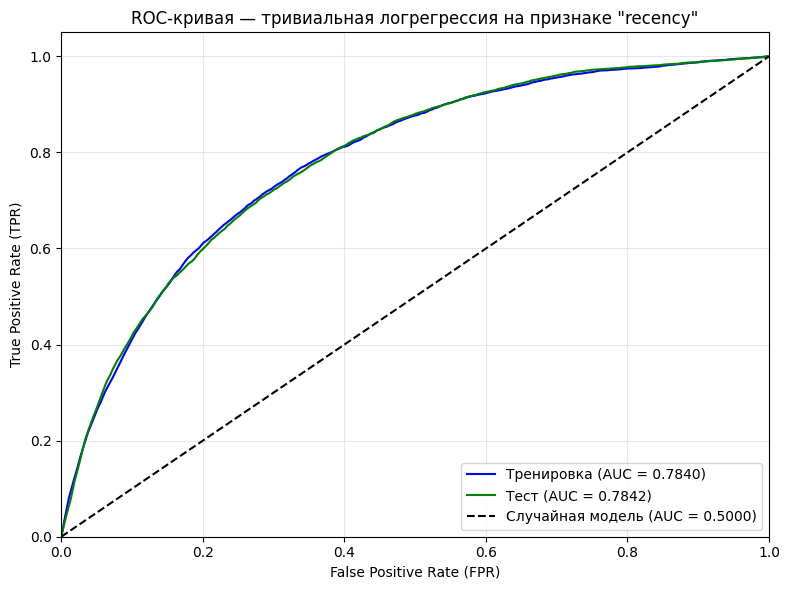

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Убедимся, что train_data и test_data загружены
train_data = pd.read_csv('data/train_data.csv')
test_data = pd.read_csv('data/test_data.csv')

# Проверка наличия нужных колонок
for df, name in [(train_data, "train_data"), (test_data, "test_data")]:
    if 'recency' not in df.columns:
        raise KeyError(f"В {name} отсутствует колонка 'recency'")
    if 'event' not in df.columns:
        raise KeyError(f"В {name} отсутствует колонка 'event'")

# Используем только один признак: recency (давность)
# Чем меньше recency — тем "свежее" клиент → выше вероятность возврата
X_train = train_data[['recency']]
y_train = train_data['event']

X_test = test_data[['recency']]
y_test = test_data['event']

# 1. Обучение тривиальной логистической регрессии
model = LogisticRegression()
model.fit(X_train, y_train)

print("✅ Тривиальная логрегрессия обучена на признаке 'recency'")

# 2. Прогноз вероятностей
y_train_pred = model.predict_proba(X_train)[:, 1]  # вероятность класса 1
y_test_pred = model.predict_proba(X_test)[:, 1]

# 3. Расчет ROC-AUC
auc_train = roc_auc_score(y_train, y_train_pred)
auc_test = roc_auc_score(y_test, y_test_pred)

print(f"ROC-AUC (train): {auc_train:.4f}")
print(f"ROC-AUC (test):  {auc_test:.4f}")

# 4. Построение ROC-кривых
plt.figure(figsize=(8, 6))

# ROC-кривая на обучающей выборке
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred)
plt.plot(fpr_train, tpr_train, label=f'Тренировка (AUC = {auc_train:.4f})', color='blue')

# ROC-кривая на тестовой выборке
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred)
plt.plot(fpr_test, tpr_test, label=f'Тест (AUC = {auc_test:.4f})', color='green')

# Диагональ (случайное угадывание)
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель (AUC = 0.5000)')

# Оформление графика
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая — тривиальная логрегрессия на признаке "recency"')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Построй тривиальную логрегрессию на основе признака "Давность" (Recently), с расчетом ROC-AUC метрики и построением ROC-кривой. 2 раза, на основе обучающей и тестовой выборки

✅ Загружено: train_data — 39906, test_data — 41196
✅ Многофакторная логрегрессия обучена на всех признаках
ROC-AUC (train): 0.8012
ROC-AUC (test):  0.8025


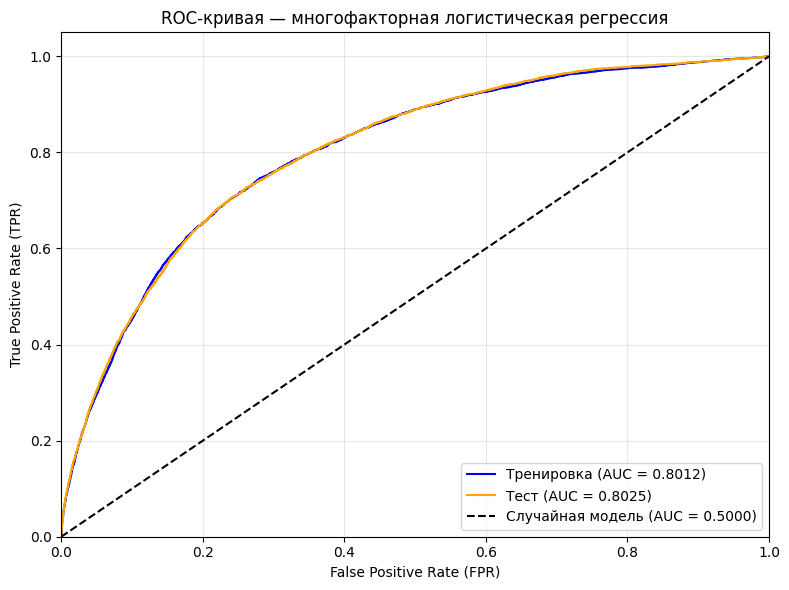


📊 Важность признаков (по модулю коэффициента):
               feature  coefficient
4              recency    -1.237162
0            frequency     0.585311
2       total_quantity    -0.084842
9    avg_num_of_visits    -0.082355
6  avg_items_per_visit     0.053609
5            avg_check    -0.033833
7       weekend_visits    -0.006620
8    amount_last_visit     0.005605
3   total_unique_items    -0.004743
1             monetary     0.003125


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Загрузка данных
train_data = pd.read_csv('data/train_data.csv')
test_data = pd.read_csv('data/test_data.csv')

print(f"✅ Загружено: train_data — {len(train_data)}, test_data — {len(test_data)}")

# 2. Выбор всех признаков (все, кроме 'client', если он есть, и 'event')
feature_columns = [col for col in train_data.columns if col not in ['client', 'event']]

X_train = train_data[feature_columns]
y_train = train_data['event']

X_test = test_data[feature_columns]
y_test = test_data['event']

# 3. Проверка на пропуски
assert not X_train.isnull().any().any(), "Пропуски в X_train"
assert not X_test.isnull().any().any(), "Пропуски в X_test"

# 4. Масштабирование признаков (важно для логрегрессии)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Обучение многофакторной логистической регрессии
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("✅ Многофакторная логрегрессия обучена на всех признаках")

# 6. Прогноз вероятностей
y_train_pred = model.predict_proba(X_train_scaled)[:, 1]
y_test_pred = model.predict_proba(X_test_scaled)[:, 1]

# 7. Расчет ROC-AUC
auc_train = roc_auc_score(y_train, y_train_pred)
auc_test = roc_auc_score(y_test, y_test_pred)

print(f"ROC-AUC (train): {auc_train:.4f}")
print(f"ROC-AUC (test):  {auc_test:.4f}")

# 8. Построение ROC-кривых
plt.figure(figsize=(8, 6))

# Кривая на train
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred)
plt.plot(fpr_train, tpr_train, label=f'Тренировка (AUC = {auc_train:.4f})', color='blue')

# Кривая на test
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred)
plt.plot(fpr_test, tpr_test, label=f'Тест (AUC = {auc_test:.4f})', color='orange')

# Диагональ — случайная модель
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель (AUC = 0.5000)')

# Оформление
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая — многофакторная логистическая регрессия')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. (Опционально) Вывод важности признаков
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': model.coef_[0]
}).sort_values(by='coefficient', key=abs, ascending=False)

print("\n📊 Важность признаков (по модулю коэффициента):")
print(feature_importance)

Построй корреляционную матрицу используя все признаки. Используй метод pandas.DataFrame.corr() к набору числовых переменных, включая
предварительно преобразованные WoE-признаки, что позволит получить матрицу попарных коэффициентов корреляции. Визуализируй матрицу в виде тепловой карты с ичпользованием seaborn.heatmap.

✅ Загружено: train_woe — 39906 строк, test_woe — 41196 строк
✅ Объединённый датасет: (81102, 10)
📊 Используемые признаки для корреляционной матрицы: ['recency', 'frequency', 'monetary', 'total_quantity', 'total_unique_items', 'avg_check', 'avg_items_per_visit', 'weekend_visits', 'amount_last_visit']


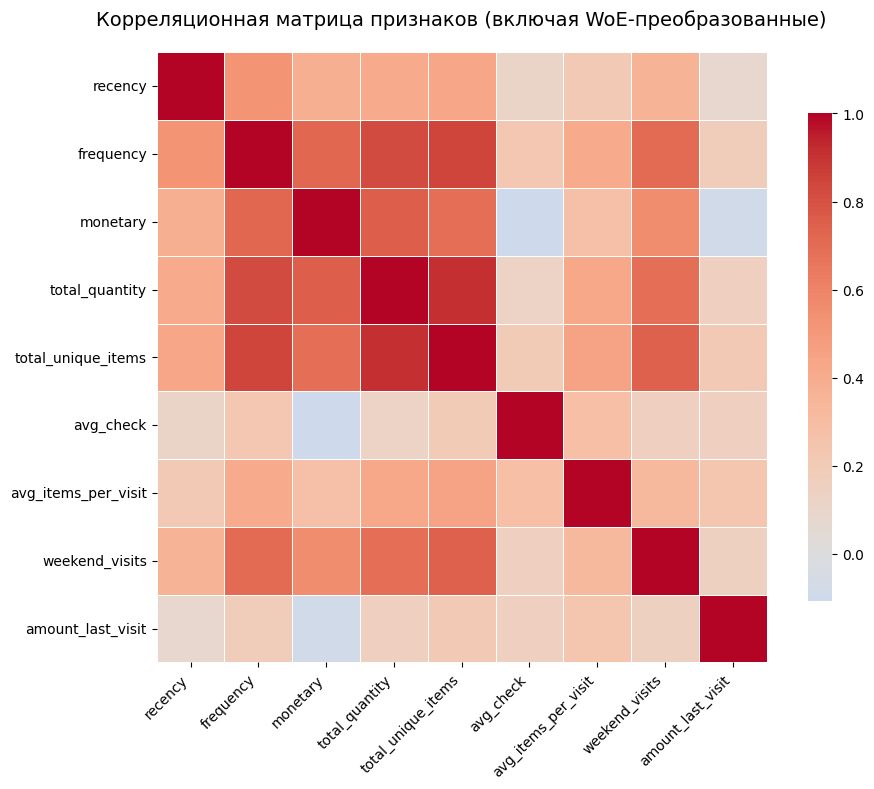

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Загрузка WoE-преобразованных данных
train_woe = pd.read_csv('data/train_woe.csv')
test_woe = pd.read_csv('data/test_woe.csv')

print(f"✅ Загружено: train_woe — {len(train_woe)} строк, test_woe — {len(test_woe)} строк")

# 2. Объединим обе выборки для более стабильной оценки корреляций
data_woe = pd.concat([train_woe, test_woe], axis=0).reset_index(drop=True)

# Убедимся, что целевая переменная 'event' остаётся
print(f"✅ Объединённый датасет: {data_woe.shape}")

# 3. Выбор всех числовых признаков (включая 'event')
# WoE-признаки уже числовые, так что просто оставляем числовые столбцы
numeric_data = data_woe.select_dtypes(include=['number'])

print(f"📊 Используемые признаки для корреляционной матрицы: {list(numeric_data.columns)}")

# 4. Расчёт корреляционной матрицы
correlation_matrix = numeric_data.corr(method='pearson')

# 5. Визуализация: тепловая карта
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=False,           # Можно включить True, если нужно числа
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Корреляционная матрица признаков (включая WoE-преобразованные)', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Построй модель XGBoost с выводом значимости признаков (feature importance)

✅ Загружено: train_woe — 39906, test_woe — 41196
📊 Количество признаков: 9
Обучение модели XGBoost...
✅ Обучение завершено
ROC-AUC (train): 0.8293
ROC-AUC (test):  0.8052

📊 Feature Importance — топ-10 признаков:
               feature  importance
0              recency    0.504907
1            frequency    0.263933
3       total_quantity    0.056795
2             monetary    0.033281
4   total_unique_items    0.031434
6  avg_items_per_visit    0.028408
8    amount_last_visit    0.028235
7       weekend_visits    0.026908
5            avg_check    0.026100


C:\Users\Alex\AppData\Local\Temp\ipykernel_11876\2697753795.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='viridis')


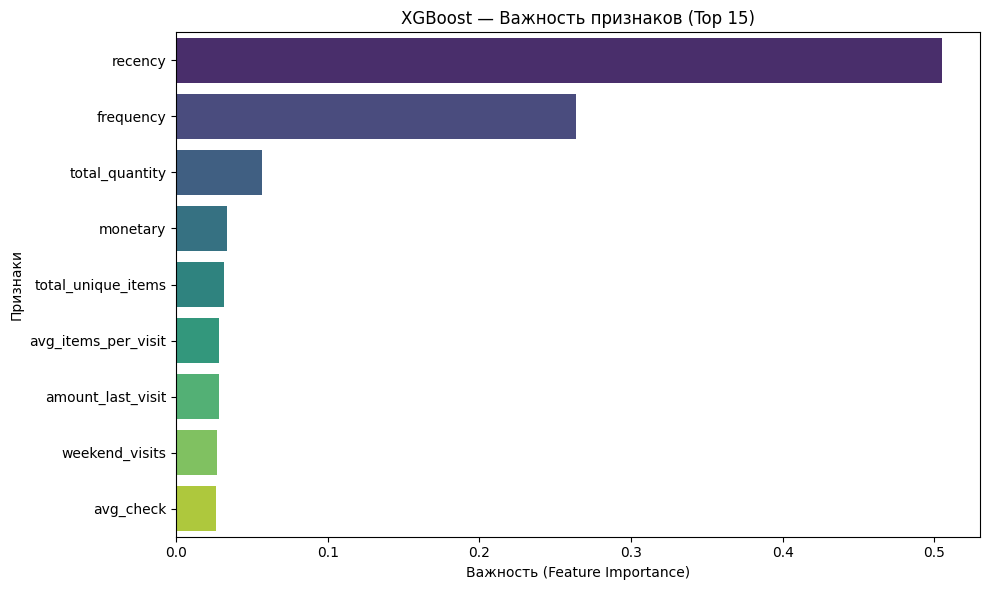

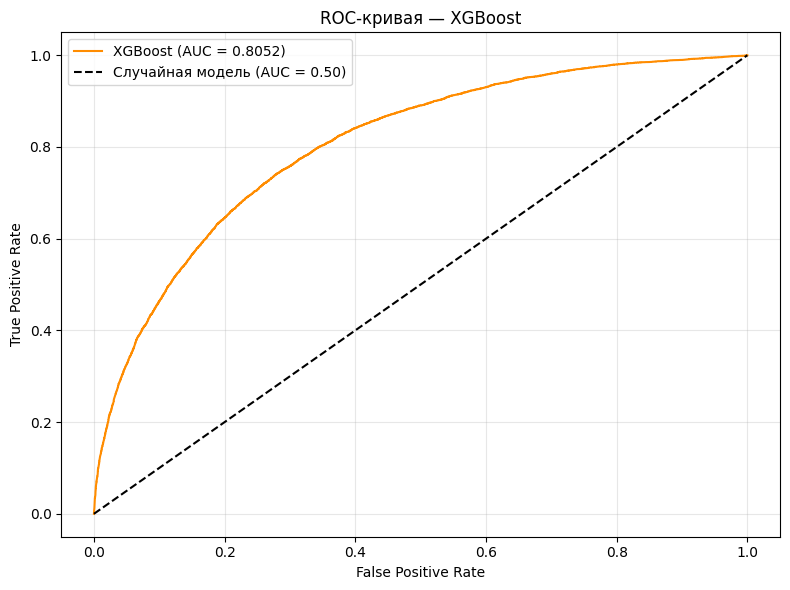

✅ Модель XGBoost сохранена в 'xgb_model.pkl'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# 1. Загрузка данных (используем WoE-преобразованные признаки)
train_woe = pd.read_csv('data/train_woe.csv')
test_woe = pd.read_csv('data/test_woe.csv')

print(f"✅ Загружено: train_woe — {len(train_woe)}, test_woe — {len(test_woe)}")

# 2. Разделение на признаки и целевую переменную
X_train = train_woe.drop('event', axis=1)
y_train = train_woe['event']

X_test = test_woe.drop('event', axis=1)
y_test = test_woe['event']

print(f"📊 Количество признаков: {X_train.shape[1]}")

# 3. Обучение модели XGBoost
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

print("Обучение модели XGBoost...")
model.fit(X_train, y_train)
print("✅ Обучение завершено")

# 4. Прогноз вероятностей
y_train_pred = model.predict_proba(X_train)[:, 1]
y_test_pred = model.predict_proba(X_test)[:, 1]

# 5. Расчет ROC-AUC
auc_train = roc_auc_score(y_train, y_train_pred)
auc_test = roc_auc_score(y_test, y_test_pred)

print(f"ROC-AUC (train): {auc_train:.4f}")
print(f"ROC-AUC (test):  {auc_test:.4f}")

# 6. Вывод важности признаков (feature importance)
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\n📊 Feature Importance — топ-10 признаков:")
print(importance_df.head(10))

# 7. Визуализация важности признаков
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='viridis')
plt.title('XGBoost — Важность признаков (Top 15)')
plt.xlabel('Важность (Feature Importance)')
plt.ylabel('Признаки')
plt.tight_layout()
plt.show()

# Дополнительно: ROC-кривая (по желанию)
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred)
plt.plot(fpr_test, tpr_test, label=f'XGBoost (AUC = {auc_test:.4f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая — XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
import pickle

# Сохранение модели XGBoost в файл
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Модель XGBoost сохранена в 'xgb_model.pkl'")

Построй прогноз на следующий месяц, (ноябрь), по которому имеются транзакционные данные, отсортируй прогнозы по убыванию вероятности наступления события. Итоговый датасет сохрани в фаил Forecast.csv. Используй данные и переменные которые уже фигурировали в коде. 

✅ Загружено: train_data — 39906, test_data — 41196
📊 ROC-AUC результаты:
Тривиальная модель (train): 0.7840
Тривиальная модель (test):  0.7842
Многофакторная модель (train): 0.8012
Многофакторная модель (test):  0.8025


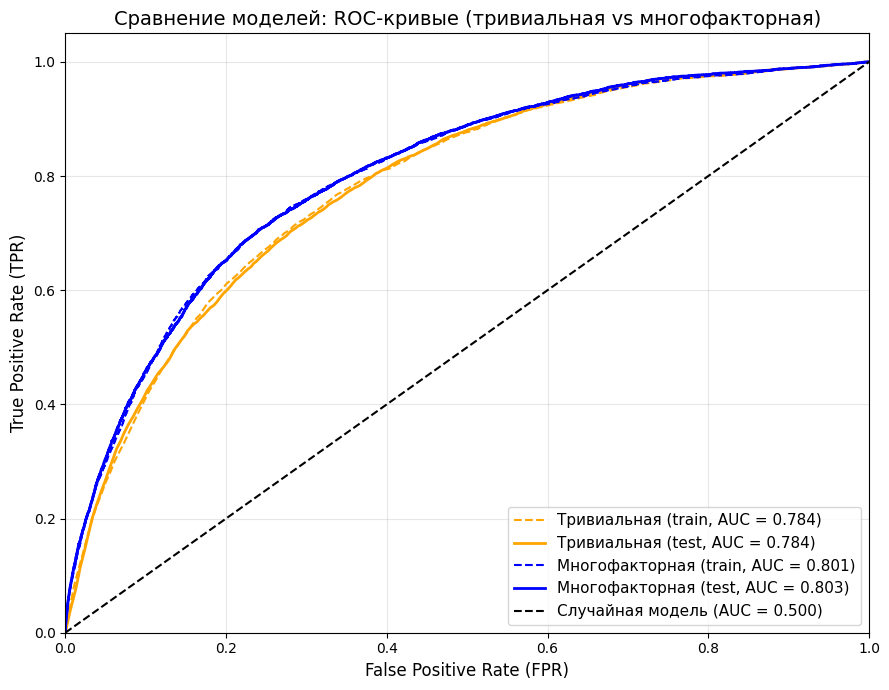

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# --- 1. Загрузка данных ---
train_data = pd.read_csv('data/train_data.csv')
test_data = pd.read_csv('data/test_data.csv')

print(f"✅ Загружено: train_data — {len(train_data)}, test_data — {len(test_data)}")

# --- 2. Подготовка данных ---
# Общие признаки
feature_cols = [col for col in train_data.columns if col not in ['client', 'event']]

X_train = train_data[feature_cols]
y_train = train_data['event']

X_test = test_data[feature_cols]
y_test = test_data['event']

# Масштабирование для логрегрессии
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 3. Тривиальная модель (только 'recency') ---
X_train_recency = train_data[['recency']]
X_test_recency = test_data[['recency']]

# Масштабируем отдельно
X_train_rec_scaled = scaler.fit_transform(X_train_recency)
X_test_rec_scaled = scaler.transform(X_test_recency)

# Обучение тривиальной модели
model_trivial = LogisticRegression(random_state=42)
model_trivial.fit(X_train_rec_scaled, y_train)

# Прогнозы
y_train_pred_trivial = model_trivial.predict_proba(X_train_rec_scaled)[:, 1]
y_test_pred_trivial = model_trivial.predict_proba(X_test_rec_scaled)[:, 1]

# --- 4. Многофакторная модель (все признаки) ---
model_full = LogisticRegression(random_state=42, max_iter=1000)
model_full.fit(X_train_scaled, y_train)

# Прогнозы
y_train_pred_full = model_full.predict_proba(X_train_scaled)[:, 1]
y_test_pred_full = model_full.predict_proba(X_test_scaled)[:, 1]

# --- 5. Расчет ROC-AUC ---
auc_train_trivial = roc_auc_score(y_train, y_train_pred_trivial)
auc_test_trivial = roc_auc_score(y_test, y_test_pred_trivial)

auc_train_full = roc_auc_score(y_train, y_train_pred_full)
auc_test_full = roc_auc_score(y_test, y_test_pred_full)

print("📊 ROC-AUC результаты:")
print(f"Тривиальная модель (train): {auc_train_trivial:.4f}")
print(f"Тривиальная модель (test):  {auc_test_trivial:.4f}")
print(f"Многофакторная модель (train): {auc_train_full:.4f}")
print(f"Многофакторная модель (test):  {auc_test_full:.4f}")

# --- 6. Построение ROC-кривых на одном графике ---
plt.figure(figsize=(9, 7))

# Тривиальная модель — обучение
fpr_train_triv, tpr_train_triv, _ = roc_curve(y_train, y_train_pred_trivial)
plt.plot(fpr_train_triv, tpr_train_triv, 
         label=f'Тривиальная (train, AUC = {auc_train_trivial:.3f})', 
         color='orange', linestyle='--')

# Тривиальная модель — тест
fpr_test_triv, tpr_test_triv, _ = roc_curve(y_test, y_test_pred_trivial)
plt.plot(fpr_test_triv, tpr_test_triv, 
         label=f'Тривиальная (test, AUC = {auc_test_trivial:.3f})', 
         color='orange', linewidth=2)

# Многофакторная модель — обучение
fpr_train_full, tpr_train_full, _ = roc_curve(y_train, y_train_pred_full)
plt.plot(fpr_train_full, tpr_train_full, 
         label=f'Многофакторная (train, AUC = {auc_train_full:.3f})', 
         color='blue', linestyle='--')

# Многофакторная модель — тест
fpr_test_full, tpr_test_full, _ = roc_curve(y_test, y_test_pred_full)
plt.plot(fpr_test_full, tpr_test_full, 
         label=f'Многофакторная (test, AUC = {auc_test_full:.3f})', 
         color='blue', linewidth=2)

# Диагональ — случайная модель
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель (AUC = 0.500)')

# Оформление
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Сравнение моделей: ROC-кривые (тривиальная vs многофакторная)', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import pickle
from datetime import datetime

# 1. Используем test_data как основу (профиль на 2019-10-01 + факт посещения в октябре)
# Теперь мы хотим ПРОГНОЗИРОВАТЬ событие в НОЯБРЕ, используя тот же подход

if 'test_data' not in globals():
    raise ValueError("Переменная 'test_data' не найдена. Убедитесь, что она создана: create_training_sample(profile2, events2)")

print(f"✅ Используем test_data для прогноза: {len(test_data)} клиентов")

# Удалим целевую переменную из октября (она нам не нужна для прогноза на ноябрь)
X_november = test_data.drop(columns=['event'], errors='ignore')  # сохраняем client
print("✅ Признаки для прогноза на ноябрь подготовлены")

# Сохраним client
clients = X_november[['client']].copy()
X_november = X_november.drop(columns=['client'], errors='ignore')

# Приведение к числовому типу
X_november = X_november.apply(pd.to_numeric, errors='coerce')

# Заполнение NaN (если есть)
X_november.fillna(X_november.mean(numeric_only=True), inplace=True)

# 2. Загрузка binning_process для WoE-трансформации
try:
    with open("binning_process.pkl", "rb") as f:
        binning_process = pickle.load(f)
    print("✅ binning_process.pkl загружен")
except FileNotFoundError:
    raise FileNotFoundError("Файл 'binning_process.pkl' не найден. Обучите и сохраните его.")

# 3. WoE-трансформация
try:
    X_november_woe = binning_process.transform(X_november, metric="woe")
    print("✅ Данные трансформированы в WoE")
except Exception as e:
    raise RuntimeError(f"Ошибка при трансформации WoE: {e}")

# 4. Загрузка обученной модели XGBoost
try:
    with open("xgb_model.pkl", "rb") as f:
        model = pickle.load(f)
    print("✅ Модель XGBoost загружена")
except FileNotFoundError:
    raise FileNotFoundError("Файл 'xgb_model.pkl' не найден. Обучите и сохраните модель.")

# 5. Прогноз вероятности события в ноябре 2019
probabilities = model.predict_proba(X_november_woe)[:, 1]

# 6. Формирование итогового прогноза
forecast_start_date = datetime(2019, 11, 1)
forecast_end_date = datetime(2019, 11, 30)

forecast_df = pd.DataFrame({
    'client': clients['client'],
    'probability': probabilities,
    'forecast_date': forecast_start_date.date(),
    'prediction_period': f"{forecast_start_date.date()} – {forecast_end_date.date()}"
})
if visits_df.empty:
    raise ValueError("visits_df пуст. Нечего фильтровать.")
if historical_data.empty:
    raise ValueError(f"Нет данных до {observation_end_date}. Проверьте диапазон дат.")
if not isinstance(profile_df, pd.DataFrame) or not isinstance(events_df, pd.DataFrame):
    raise TypeError("Ожидаются DataFrame")
# Вместо:
events1 = mark_events(..., '2019-09-01', '2019-10-01')

# Лучше:
TRAIN_START = '2019-09-01'
TRAIN_END = '2019-10-01'
events1 = mark_events(visits_df, TRAIN_START, TRAIN_END)
def create_training_sample(profile_df: pd.DataFrame, events_df: pd.DataFrame) -> pd.DataFrame:
OBSERVATION_DATE = '2019-09-01'
EVENT_START, EVENT_END = '2019-09-01', '2019-10-01'

# Сортировка по убыванию вероятности
forecast_df = forecast_df.sort_values(by='probability', ascending=False).reset_index(drop=True)

# 7. Сохранение результата
forecast_df.to_csv("Forecast.csv", index=False)

print("✅ Прогноз на ноябрь 2019 успешно сохранён в 'Forecast.csv'")
print(f"📈 Размер: {len(forecast_df)} клиентов")
print(f"🔝 Топ-5 клиентов по вероятности возврата:")
print(forecast_df.head())

✅ Используем test_data для прогноза: 41196 клиентов
✅ Признаки для прогноза на ноябрь подготовлены
✅ binning_process.pkl загружен
✅ Данные трансформированы в WoE
✅ Модель XGBoost загружена
✅ Прогноз на ноябрь 2019 успешно сохранён в 'Forecast.csv'
📈 Размер: 41196 клиентов
🔝 Топ-5 клиентов по вероятности возврата:
        client  probability forecast_date        prediction_period
0  client24160     0.917153    2019-11-01  2019-11-01 – 2019-11-30
1  client24709     0.917153    2019-11-01  2019-11-01 – 2019-11-30
2   client7236     0.913683    2019-11-01  2019-11-01 – 2019-11-30
3  client40070     0.913683    2019-11-01  2019-11-01 – 2019-11-30
4  client33652     0.908906    2019-11-01  2019-11-01 – 2019-11-30
